# Customer Churn Analysis – Business Perspective

## Objective
This analysis aims to understand the main factors driving customer churn. By identifying patterns in customer behavior, the goal is to help the company improve retention strategies and reduce customer loss.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview
The dataset contains information about customers, their services, account details, and whether they churned. The data was cleaned by converting the `TotalCharges` column to numeric format and removing missing values.

In [4]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


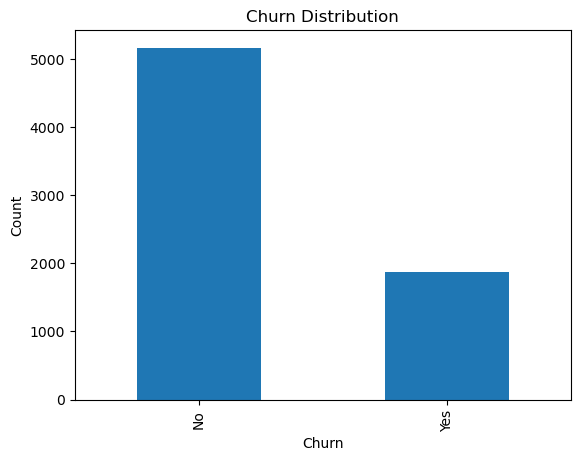

In [6]:
df['Churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## Overall Churn Rate
Approximately 26.6% of customers churned, which represents a significant portion of the customer base. This indicates that customer retention is a major challenge for the company and requires further investigation.

In [7]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


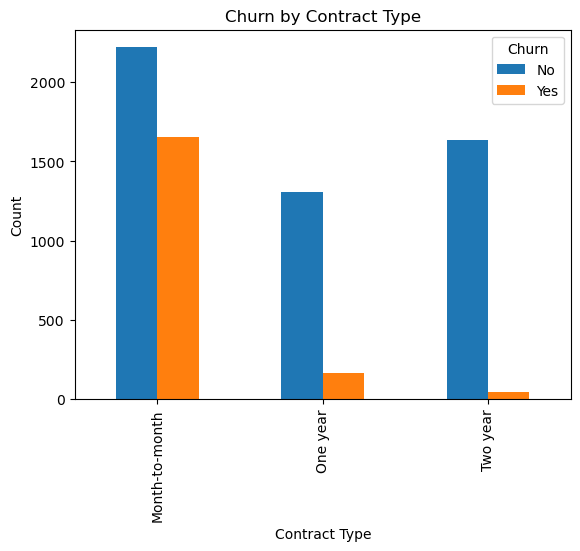

In [8]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

## Churn by Contract Type
Customers with month-to-month contracts have the highest churn rate compared to those with longer-term contracts. 

Customers with one-year and two-year contracts are significantly more stable, suggesting that contract length plays a key role in customer retention.

In [11]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


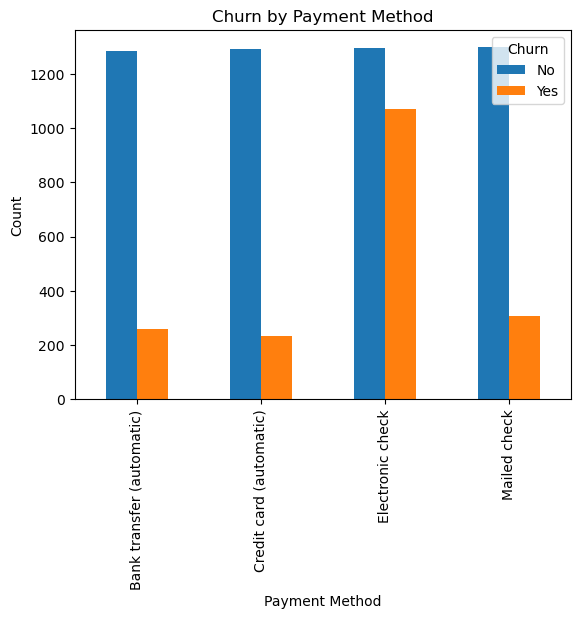

In [10]:
pd.crosstab(df['PaymentMethod'], df['Churn']).plot(kind='bar')

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

## Churn by Payment Method
Customers using electronic check show the highest churn rate among all payment methods.

In contrast, customers using automatic payment methods such as credit card or bank transfer are more likely to stay, indicating that payment behavior is strongly linked to customer retention.

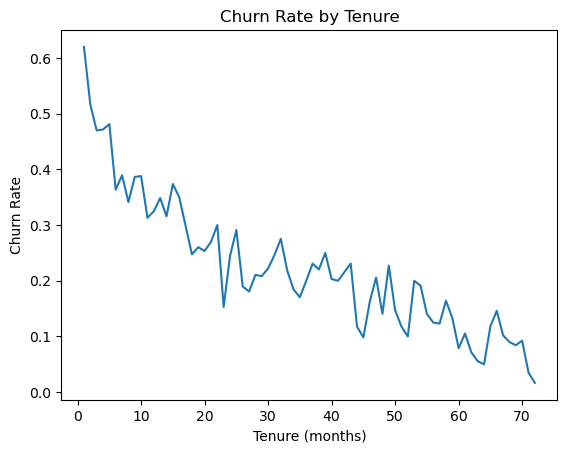

In [12]:
tenure_churn = df.groupby('tenure')['Churn'].value_counts(normalize=True).unstack()
tenure_churn['Yes'].plot()

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate")
plt.show()

## Churn by Tenure
Churn is significantly higher among new customers and decreases as tenure increases.

This indicates that the first few months are critical for customer retention. Customers who stay longer are much less likely to churn, suggesting increased loyalty over time.

## Final Business Insights
The analysis reveals several key drivers of customer churn:

- Customers on month-to-month contracts are more likely to churn
- Customers using electronic check show higher churn rates
- New customers are significantly more likely to leave compared to long-term customers

These findings suggest that the company should focus on improving early customer experience, encouraging long-term contracts, and promoting automatic payment methods to reduce churn and improve retention.